<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>

</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>

<hr/>
<font color="#800080" size=5>
Assignment 3
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>
<!-- <font face="Times New Roman" size=4>
Deadline:
</font> -->
<hr>
</div></font>

name = "Amir Kooshan Fattah Hesari"

studentId = "401102191"

It is recommended to open this notebook in Google Colab from [here](https://colab.research.google.com/drive/1oRa8tpMWx52pxfydpwQloKIYseZOA-z2?usp=sharing) and create a copy. You can comment your questions on the notebook as well.

In this exercise we want to gain hands-on experience with Normalizing Flow Models.
1. We want to implement simple flow models from scratch. (GPU not required)
2. We will use a flow model to perform image in-painting. (GPU recommended)

# Section 1: Flow From Scratch

In [1]:
# @title imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as D
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from tqdm import tqdm
import numpy as np

import time

In [2]:
# @title settings
# @title settings

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Transforms

One of the challenges in creating flow models is creating **invertible** transformations with computable **Jacobian determinant**. We will create such transformations now.

In [3]:
# @title Base Transform classes / helpers

class InverseNotAvailable(Exception):
    pass

class Transform(nn.Module):
    """Base class for invertible transform objects.

    Every transform.forward returns (y, log_det_J) where log_det_J is a tensor
    shaped (batch,) or a scalar (will be broadcasted).
    inverse(...) should return the inverse mapping (no log-det returned).
    """
    def forward(self, inputs, context=None):
        raise NotImplementedError()

    def inverse(self, inputs, context=None):
        raise InverseNotAvailable()

First lets create a permutation transform

In [7]:
class PermutationTransform(Transform):
    def __init__(self, num_features, permutation=None):
        super().__init__()
        if permutation is None:
            permutation = torch.randperm(num_features)
        else:
            permutation = torch.as_tensor(permutation, dtype=torch.long)

        self.register_buffer('permutation', permutation)
        self.register_buffer('inverse_permutation', torch.argsort(permutation))

    def forward(self, inputs: torch.Tensor, context: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        """Apply permutation to input features.
        
        Args:
            inputs: Input tensor of shape (batch, ..., num_features)
            context: Unused, kept for API consistency
        
        Returns:
            outputs: Permuted tensor, same shape as inputs
            log_det: Zero log determinant (scalar or shape (batch,))
        """
        # Permute along the last dimension
        outputs = inputs[..., self.permutation]
        
        # Permutation has determinant ±1, so log|det| = 0
        # Return scalar 0 (will broadcast to batch size)
        log_det = torch.zeros(inputs.shape[0], device=inputs.device, dtype=inputs.dtype)
        
        return outputs, log_det
    
    def inverse(self, inputs: torch.Tensor, context: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Apply inverse permutation
        return inputs[..., self.inverse_permutation]

Now create an ActNorm Transform. Learnable per-channel scale & bias with data-dependent init

In [10]:
class ActNorm(Transform):
    def __init__(self, num_features: int):
        super().__init__()
        self.num_features = num_features
        
        # Learnable parameters: bias and log_scale per feature
        # Shape (1, num_features) for broadcasting over batch dimension
        self.bias = nn.Parameter(torch.zeros(1, num_features))
        self.log_scale = nn.Parameter(torch.zeros(1, num_features))
        
        # Flag to track if data-dependent initialization has been performed
        self.register_buffer('initialized', torch.tensor(False))
    
    def forward(self, x: torch.Tensor, context: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        # Data-dependent initialization on first batch during training
        if not self.initialized and self.training:
            with torch.no_grad():
                # Flatten all dimensions except the last (features)
                x_flat = x.view(-1, self.num_features)  # (batch*..., num_features)
                
                # Compute per-feature statistics over all samples
                mean = x_flat.mean(dim=0, keepdim=True)  # (1, num_features)
                std = x_flat.std(dim=0, keepdim=True)    # (1, num_features)
                
                # Initialize to normalize: y = (x - mean) / std
                # Our transform is: y = (x + bias) * exp(log_scale)
                # So: (x + bias) * exp(log_scale) = (x - mean) / std
                # Therefore: bias = -mean, log_scale = -log(std)
                self.bias.data.copy_(-mean)
                self.log_scale.data.copy_(-torch.log(std + 1e-6))  # Add epsilon for stability
                
                self.initialized.fill_(True)
        
        # Apply ActNorm transformation: y = (x + bias) * exp(log_scale)
        y = (x + self.bias) * torch.exp(self.log_scale)
        
        # Compute log determinant
        # For affine transform y = scale * x + bias, det(J) = product of scales
        # log|det(J)| = sum of log|scales| = sum of log_scale (over features)
        # Need to multiply by number of non-feature dimensions for proper volume scaling
        
        # Count how many elements each feature dimension affects
        # e.g., for (batch, H, W, features), each feature scales H*W elements
        feature_size = x.numel() // (x.shape[0] * self.num_features)  # H*W*... per batch sample
        
        # Log det is sum of log_scale, scaled by feature_size, per batch element
        log_det = torch.sum(self.log_scale) * feature_size
        log_det = log_det.expand(x.shape[0])  # (batch,)
        
        return y, log_det
    
    def inverse(self, y: torch.Tensor, context: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Inverse: x = y * exp(-log_scale) - bias
        x = y * torch.exp(-self.log_scale) - self.bias
        return x


Create an invertible linear (dense) layer with orthogonal / LU parametrization. Inspired by the 1x1 convolution used in Glow.

In [11]:
class InvertibleLinear(Transform):
    
    def __init__(self, num_features: int, use_lu: bool = False):
        super().__init__()
        self.num_features = num_features
        self.use_lu = use_lu
        
        # ---- Option 1: Full matrix (default) ----
        if not use_lu:
            # Initialize a random orthogonal matrix using QR decomposition
            random_matrix = torch.randn(num_features, num_features)
            q, r = torch.linalg.qr(random_matrix)
            # Ensure positive diagonal of R for uniqueness
            q = q @ torch.diag(torch.sign(torch.diag(r)))
            self.weight = nn.Parameter(q)
            return
        
        # ---- Option 2: LU parameterization ----
        # Initialize a random orthogonal matrix
        random_matrix = torch.randn(num_features, num_features)
        q, r = torch.linalg.qr(random_matrix)
        q = q @ torch.diag(torch.sign(torch.diag(r)))
        
        # Get LU decomposition
        P, L, U = torch.linalg.lu(q)
        
        # Store permutation matrix P as buffer (not trainable)
        self.register_buffer("P", P)
        
        # Mask for L: strictly lower triangle + identity diagonal
        L_mask = torch.tril(torch.ones(num_features, num_features), diagonal=-1)
        self.register_buffer("L_mask", L_mask)
        
        # Mask for U: upper triangle (excluding diagonal, we'll handle it separately)
        U_mask = torch.triu(torch.ones(num_features, num_features), diagonal=1)
        self.register_buffer("U_mask", U_mask)
        
        # Create learnable parameters for L and U
        self.L_params = nn.Parameter(L * L_mask)  # strictly lower triangle
        self.U_params = nn.Parameter(U * U_mask)  # upper triangle (no diagonal)
        
        # Store diagonal of U separately in log space for numerical stability
        self.log_diag_U = nn.Parameter(torch.log(torch.abs(torch.diag(U)) + 1e-6))
    
    def _assemble_weight(self) -> torch.Tensor:
        if not self.use_lu:
            return self.weight
        
        # Reconstruct L: strictly lower triangle + identity diagonal
        L = self.L_params * self.L_mask + torch.eye(self.num_features, device=self.L_params.device)
        
        # Reconstruct U: upper triangle + exp(log_diag_U) for diagonal
        U = self.U_params * self.U_mask + torch.diag(torch.exp(self.log_diag_U))
        
        # Final weight: W = P @ L @ U
        W = self.P @ L @ U
        return W
    
    def forward(self, x: torch.Tensor, context: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        W = self._assemble_weight()
        
        # Apply transformation: y = x @ W^T
        y = x @ W.t()
        
        if self.use_lu:
            # Efficient log-det: sum of log diagonal elements of U
            # For W = P @ L @ U: det(W) = det(P) * det(L) * det(U)
            # det(P) = ±1, det(L) = 1, det(U) = product of diagonal
            log_det = torch.sum(self.log_diag_U)
            log_det = log_det * torch.ones(x.size(0), device=x.device)
        else:
            # Full matrix: compute log-det directly (slower)
            sign, logabsdet = torch.linalg.slogdet(W)
            log_det = logabsdet * torch.ones(x.size(0), device=x.device)
        
        return y, log_det
    
    def inverse(self, y: torch.Tensor, context: Optional[torch.Tensor] = None) -> torch.Tensor:
        W = self._assemble_weight()
        W_inv = torch.inverse(W)
        return y @ W_inv.t()

Now  lets create a simple Affine Coupling Transform. From RealNVP.

$$y_d = x_d * \exp(s(x_a)) + t(x_a)$$

In [14]:
from typing import Optional, Tuple, List, Union, Callable

class AffineCouplingTransform(Transform):
    def __init__(
        self, 
        mask: Union[torch.Tensor, List, Tuple], 
        hidden_dims: int = 128,
        s_net_f: Optional[Callable] = None,
        t_net_f: Optional[Callable] = None
    ):
        super().__init__()
        
        # Validate and register mask
        mask = torch.as_tensor(mask, dtype=torch.float32)
        if mask.dim() != 1:
            raise ValueError("Mask must be a 1-dim tensor.")
        if mask.numel() <= 0:
            raise ValueError("Mask can't be empty.")
        
        self.register_buffer('mask', mask)
        self.num_features = self.mask.numel()
        
        # Compute indices for identity and transform parts
        features_vector = torch.arange(self.num_features)
        self.identity_idx = features_vector[self.mask == 0]
        self.transform_idx = features_vector[self.mask == 1]
        
        in_dim = len(self.identity_idx)   # conditioning features
        out_dim = len(self.transform_idx)  # transformed features
        
        if in_dim == 0:
            raise ValueError("Mask must have at least one identity feature (mask=0)")
        if out_dim == 0:
            raise ValueError("Mask must have at least one transform feature (mask=1)")
        
        # Create scale and translation networks
        if s_net_f is None:
            self.s = self._net(in_dim, out_dim, hidden_dims)
        else:
            self.s = s_net_f(in_dim, out_dim, hidden_dims)
        
        if t_net_f is None:
            self.t = self._net(in_dim, out_dim, hidden_dims)
        else:
            self.t = t_net_f(in_dim, out_dim, hidden_dims)
        
        # Initialize last layer to zeros for stable initial transforms
        self._initialize_last_layer(self.s)
        self._initialize_last_layer(self.t)
    
    def _net(self, input_dim: int, output_dim: int, hidden_dims: int) -> nn.Module:
        net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, hidden_dims),
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim)
        )
        return net
    
    def _initialize_last_layer(self, network: nn.Module):
        """Initialize the last layer weights and biases to zero for stable training."""
        if isinstance(network, nn.Sequential):
            last_layer = network[-1]
            if isinstance(last_layer, nn.Linear):
                nn.init.zeros_(last_layer.weight)
                nn.init.zeros_(last_layer.bias)
    
    def forward(self, x: torch.Tensor, context: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        if x.dim() != 2:
            raise ValueError("Expect 2D inputs of shape (batch, num_features)")
        
        # Split input into identity and transform parts
        x_id = x[:, self.identity_idx]  # (batch, in_dim) - conditioning
        x_tr = x[:, self.transform_idx]  # (batch, out_dim) - to be transformed
        
        # Compute scale and translation from identity features
        s_out = self.s(x_id)  # (batch, out_dim)
        t_out = self.t(x_id)  # (batch, out_dim)
        
        # Apply tanh to constrain scale to reasonable range (-2, 2)
        # This prevents numerical instability from extreme scales early in training
        s_out = torch.tanh(s_out) * 2.0
        
        # Apply affine transformation: y = x * exp(s) + t
        y_tr = x_tr * torch.exp(s_out) + t_out
        
        # Assemble output: identity features unchanged, transform features modified
        y = x.clone()
        y[:, self.identity_idx] = x_id
        y[:, self.transform_idx] = y_tr
        
        # Compute log determinant
        # For affine coupling: det(J) = product of exp(s_i) over transformed features
        # log|det(J)| = sum of s_i over transformed features
        log_det = torch.sum(s_out, dim=1)  # (batch,)
        
        return y, log_det
    
    def inverse(self, y: torch.Tensor, context: Optional[torch.Tensor] = None) -> torch.Tensor:
        if y.dim() != 2:
            raise ValueError("Expect 2D inputs of shape (batch, num_features)")
        
        # Split output into identity and transform parts
        y_id = y[:, self.identity_idx]  # (batch, in_dim) - unchanged
        y_tr = y[:, self.transform_idx]  # (batch, out_dim) - to be inverted
        
        # Compute scale and translation from identity features (same as forward)
        s_out = self.s(y_id)  # (batch, out_dim)
        t_out = self.t(y_id)  # (batch, out_dim)
        
        # Apply tanh constraint (same as forward)
        s_out = torch.tanh(s_out) * 2.0
        
        # Inverse affine transformation: x = (y - t) * exp(-s)
        x_tr = (y_tr - t_out) * torch.exp(-s_out)
        
        # Assemble input: identity features unchanged, transform features inverted
        x = y.clone()
        x[:, self.identity_idx] = y_id
        x[:, self.transform_idx] = x_tr
        
        return x

## Model

In this step we implement a simple Normalizing Flow model (RealNVP-like).
The model consists of:
  - a sequence of invertible transforms
  - a base Gaussian distribution
The Flow class is generic: it can (mostly) work with any sequence of invertible transforms.

In [16]:

import torch.distributions as D
class Flow(nn.Module):
   
    def __init__(
        self, 
        transforms: List[nn.Module], 
        base_distribution: Optional[D.Distribution] = None,
        device: str = 'cpu'
    ):
        
        super(Flow, self).__init__()
        self.device = device
        self.transforms = nn.ModuleList(transforms).to(device)
        
        # Infer number of features from first transform
        self.num_features = self.transforms[0].num_features
        
        # Default to standard multivariate Gaussian if no base provided
        if base_distribution is None:
            self.base_distribution = D.MultivariateNormal(
                loc=torch.zeros(self.num_features, device=device),
                covariance_matrix=torch.eye(self.num_features, device=device)
            )
        else:
            self.base_distribution = base_distribution
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
     
        # Initialize log determinant accumulator
        log_det_total = torch.zeros(x.shape[0], device=x.device)
        
        # Apply each transform in sequence
        z = x
        for transform in self.transforms:
            z, log_det = transform(z)
            log_det_total = log_det_total + log_det
        
        return z, log_det_total
    
    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        
        x = z
        # Apply inverse transforms in reverse order
        for transform in reversed(self.transforms):
            x = transform.inverse(x)
        
        return x
    
    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
       
        # Transform to latent space and get log determinant
        z, log_det_J = self.forward(x)
        
        # Compute log probability in base distribution
        log_prob_z = self.base_distribution.log_prob(z)  # (batch,)
        
        # Apply change of variables formula
        # Note: log_det_J is for x→z direction, so we ADD it (not subtract)
        # because we want log|det(dz/dx)| which is the negative of log|det(dx/dz)|
        log_prob_x = log_prob_z + log_det_J
        
        return log_prob_x
    
    def sample(self, num_samples: int) -> torch.Tensor:
        # Sample from base distribution
        z = self.base_distribution.sample((num_samples,))  # (num_samples, num_features)
        
        # Transform to data space
        x = self.inverse(z)
        
        return x
    
    def sample_and_log_prob(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Sample from base distribution
        z = self.base_distribution.sample((num_samples,))  # (num_samples, num_features)
        
        # Compute log probability in base space
        log_prob_z = self.base_distribution.log_prob(z)  # (num_samples,)
        
        # Transform to data space
        x = self.inverse(z)
        
        # Compute log determinant by forward pass
        _, log_det_J = self.forward(x)
        
        # Apply change of variables
        log_prob_x = log_prob_z + log_det_J
        
        return x, log_prob_x

Now  we initialize the model and coupling layers. We then train the model on the simple Moons dataset and visualize its learning process through its latent space.

In [17]:
# Mask helper
def make_masks(num_features, alternating=True):
    if alternating:
        return [(i % 2) for i in range(num_features)]
    else:
        return [((i+1) % 2) for i in range(num_features)]

In [19]:
def build_realnvp_flow(
    num_features: int = 2, 
    n_couplings: int = 6, 
    hidden_dims: int = 128,
    device: str = 'cpu'
) -> 'Flow':
    transforms = []
    
    # Start with ActNorm for initial normalization
    transforms.append(ActNorm(num_features))
    
    for i in range(n_couplings):
        # Create alternating mask (flip mask every other layer)
        if i % 2 == 0:
            mask = make_masks(num_features, 'alternating')
        else:
            # Flip the mask: 0→1, 1→0
            mask = 1 - make_masks(num_features, 'alternating')
        
        # Add affine coupling layer
        transforms.append(
            AffineCouplingTransform(mask, hidden_dims=hidden_dims)
        )
        
        # Add invertible linear transformation
        # Alternate between LU decomposition and full matrix
        use_lu = (i % 2 == 0)
        transforms.append(
            InvertibleLinear(num_features, use_lu=use_lu)
        )
    
    return Flow(transforms, device=device)


def build_permut_flow(
    num_features: int = 2, 
    n_couplings: int = 6, 
    hidden_dims: int = 128,
    device: str = 'cpu'
) -> 'Flow':
    transforms = []
    
    # Start with ActNorm for initial normalization
    transforms.append(ActNorm(num_features))
    
    for i in range(n_couplings):
        # Create alternating mask (flip mask every other layer)
        if i % 2 == 0:
            mask = make_masks(num_features, 'alternating')
        else:
            # Flip the mask
            mask = 1 - make_masks(num_features, 'alternating')
        
        # Add affine coupling layer
        transforms.append(
            AffineCouplingTransform(mask, hidden_dims=hidden_dims)
        )
        
        # Add random permutation (different for each layer)
        transforms.append(
            PermutationTransform(num_features, permutation=None)  # None = random
        )
    
    return Flow(transforms, device=device)


def build_glow_flow(
    num_features: int = 2,
    n_blocks: int = 3,
    hidden_dims: int = 128,
    device: str = 'cpu'
) -> 'Flow':
    transforms = []
    
    for i in range(n_blocks):
        # Glow block: ActNorm → 1x1 Conv (InvertibleLinear) → AffineCoupling
        
        # 1. ActNorm
        transforms.append(ActNorm(num_features))
        
        # 2. Invertible 1x1 convolution (implemented as InvertibleLinear with LU)
        transforms.append(InvertibleLinear(num_features, use_lu=True))
        
        # 3. Affine coupling with alternating mask
        if i % 2 == 0:
            mask = make_masks(num_features, 'alternating')
        else:
            mask = 1 - make_masks(num_features, 'alternating')
        
        transforms.append(
            AffineCouplingTransform(mask, hidden_dims=hidden_dims)
        )
    
    return Flow(transforms, device=device)

In [22]:
def train_flow(
    flow,
    X: torch.Tensor,
    num_epochs: int = 1000,
    batch_size: int = 256,
    lr: float = 1e-3,
    log_interval: int = 50,
    verbose: bool = True,
    device: str = 'cpu'
) -> Tuple['Flow', List[float]]:
    
    flow = flow.to(device)
    X = X.to(device)
    
    # Setup optimizer
    opt = optim.Adam(flow.parameters(), lr=lr)
    
    # Create data loader
    dataset = TensorDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    loss_history = []
    pbar = tqdm(range(num_epochs), disable=not verbose)
    
    for epoch in pbar:
        epoch_loss = 0.0
        num_batches = 0
        
        for (batch,) in loader:
            # Zero gradients
            opt.zero_grad()
            
            # Compute negative log-likelihood
            # log_prob returns log p(x) for each sample
            # We want to maximize log p(x), so minimize -log p(x)
            log_prob = flow.log_prob(batch)
            nll = -log_prob.mean()  # Negative log-likelihood
            
            # Backward pass and optimization step
            nll.backward()
            opt.step()
            
            # Accumulate loss
            epoch_loss += nll.item()
            num_batches += 1
        
        # Compute average epoch loss
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        
        # Logging and visualization
        if verbose and (epoch % log_interval == 0 or epoch == num_epochs - 1):
            pbar.set_description(f"Epoch {epoch} | Loss: {avg_epoch_loss:.4f}")
            
            # Visualize learned density for 2D data
            if epoch % (log_interval * 5) == 0 and X.shape[1] == 2:
                visualize_2d_density(flow, epoch, device)
    
    return flow, loss_history


def visualize_2d_density(
    flow,
    epoch: int,
    device: str = 'cpu',
    x_range: Tuple[float, float] = (-1.5, 2.5),
    y_range: Tuple[float, float] = (-0.75, 1.25),
    resolution: int = 200
):
    
    with torch.no_grad():
        # Create grid
        xline = torch.linspace(x_range[0], x_range[1], resolution, device=device)
        yline = torch.linspace(y_range[0], y_range[1], resolution, device=device)
        xgrid, ygrid = torch.meshgrid(xline, yline, indexing='ij')
        
        # Flatten grid for batch processing
        xy = torch.stack([xgrid.flatten(), ygrid.flatten()], dim=1)
        
        # Compute log probabilities
        log_prob_grid = flow.log_prob(xy)
        
        # Convert to probabilities and reshape
        prob_grid = torch.exp(log_prob_grid).reshape(resolution, resolution).cpu()
    
    # Plot density
    plt.figure(figsize=(8, 6))
    plt.contourf(
        xgrid.cpu().numpy(),
        ygrid.cpu().numpy(),
        prob_grid.numpy(),
        levels=50,
        cmap='viridis'
    )
    plt.title(f"Learned Density - Epoch {epoch}")
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.colorbar(label='Probability Density')
    plt.tight_layout()
    plt.show()


def plot_2d_data_vs_flow_samples(
    flow,
    X: torch.Tensor,
    num_samples: int = 1000,
    figsize: Tuple[int, int] = (12, 5)
):
    
    # Generate samples from the flow
    with torch.no_grad():
        samples = flow.sample(num_samples).cpu().numpy()
    
    X_np = X.cpu().numpy()
    
    # Create side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot original data
    axes[0].scatter(X_np[:, 0], X_np[:, 1], s=6, alpha=0.6, c='blue')
    axes[0].set_title("Original Data", fontsize=14)
    axes[0].set_xlabel('x₁')
    axes[0].set_ylabel('x₂')
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)
    
    # Plot flow samples
    axes[1].scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.6, c='red')
    axes[1].set_title("Flow Samples", fontsize=14)
    axes[1].set_xlabel('x₁')
    axes[1].set_ylabel('x₂')
    axes[1].axis('equal')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_training_curve(loss_history: List[float], figsize: Tuple[int, int] = (10, 5)):
 
    plt.figure(figsize=figsize)
    plt.plot(loss_history, linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Negative Log-Likelihood', fontsize=12)
    plt.title('Training Loss Curve', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_density_comparison(
    flow,
    X: torch.Tensor,
    device: str = 'cpu',
    x_range: Tuple[float, float] = (-1.5, 2.5),
    y_range: Tuple[float, float] = (-0.75, 1.25),
    resolution: int = 200,
    figsize: Tuple[int, int] = (14, 5)
):
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    X_np = X.cpu().numpy()
    
    # Plot 1: Data histogram
    axes[0].hist2d(X_np[:, 0], X_np[:, 1], bins=50, cmap='viridis')
    axes[0].set_title("Data Histogram", fontsize=14)
    axes[0].set_xlabel('x₁')
    axes[0].set_ylabel('x₂')
    
    # Plot 2: Learned density
    with torch.no_grad():
        xline = torch.linspace(x_range[0], x_range[1], resolution, device=device)
        yline = torch.linspace(y_range[0], y_range[1], resolution, device=device)
        xgrid, ygrid = torch.meshgrid(xline, yline, indexing='ij')
        xy = torch.stack([xgrid.flatten(), ygrid.flatten()], dim=1)
        log_prob_grid = flow.log_prob(xy)
        prob_grid = torch.exp(log_prob_grid).reshape(resolution, resolution).cpu()
    
    im = axes[1].contourf(
        xgrid.cpu().numpy(),
        ygrid.cpu().numpy(),
        prob_grid.numpy(),
        levels=50,
        cmap='viridis'
    )
    axes[1].set_title("Learned Density", fontsize=14)
    axes[1].set_xlabel('x₁')
    axes[1].set_ylabel('x₂')
    plt.colorbar(im, ax=axes[1], label='Density')
    
    plt.tight_layout()
    plt.show()

## Training and Evaluation

In this step you will:
  - Train two types of flows on the make_moons dataset
  - Compare their training losses
  - Visualize density contours
  - Visualize generated samples


You are encouraged to add your own configurations and their names to `flow_names` and find better results.

You may **slightly** modify the visualization codes to match your code but this is discouraged.

In [24]:
from torch.utils.data import DataLoader, TensorDataset



=== Building & training flow: RealNVP ===


Epoch 0 | Loss: 1.8283:   0%|          | 0/1000 [00:00<?, ?it/s]

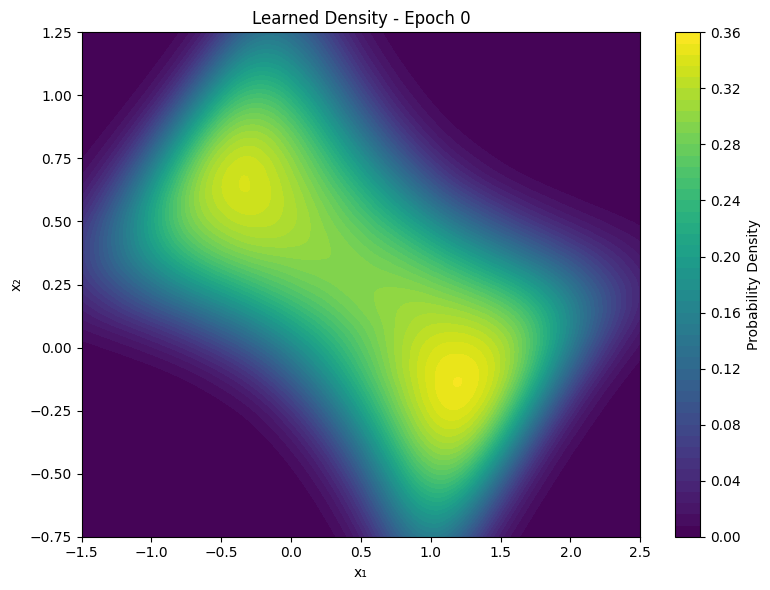

Epoch 250 | Loss: 0.8149:  25%|██▌       | 250/1000 [00:56<02:51,  4.37it/s]

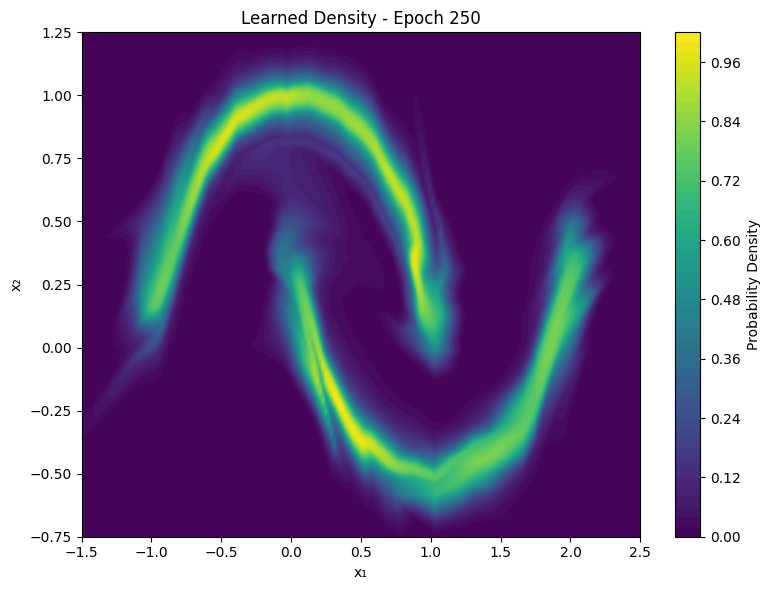

Epoch 500 | Loss: 0.8130:  50%|█████     | 500/1000 [01:53<02:19,  3.58it/s]

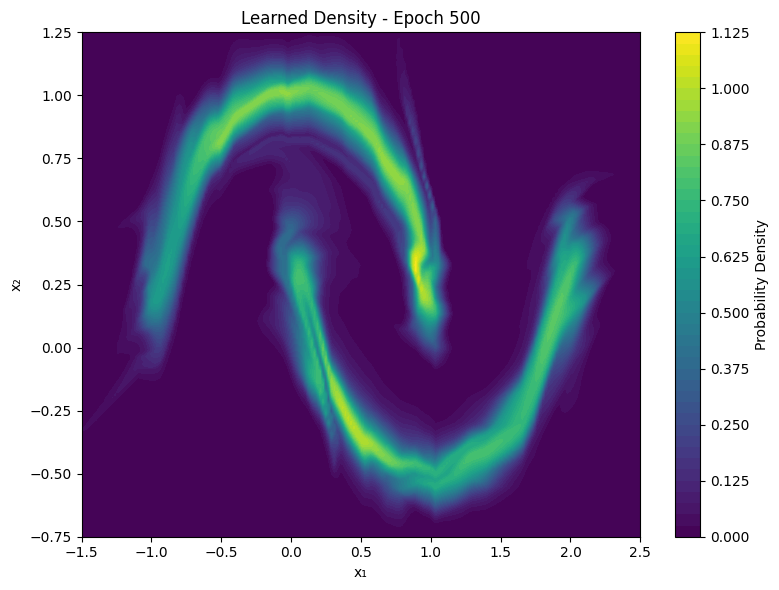

Epoch 750 | Loss: 0.7543:  75%|███████▌  | 750/1000 [02:51<00:56,  4.42it/s]

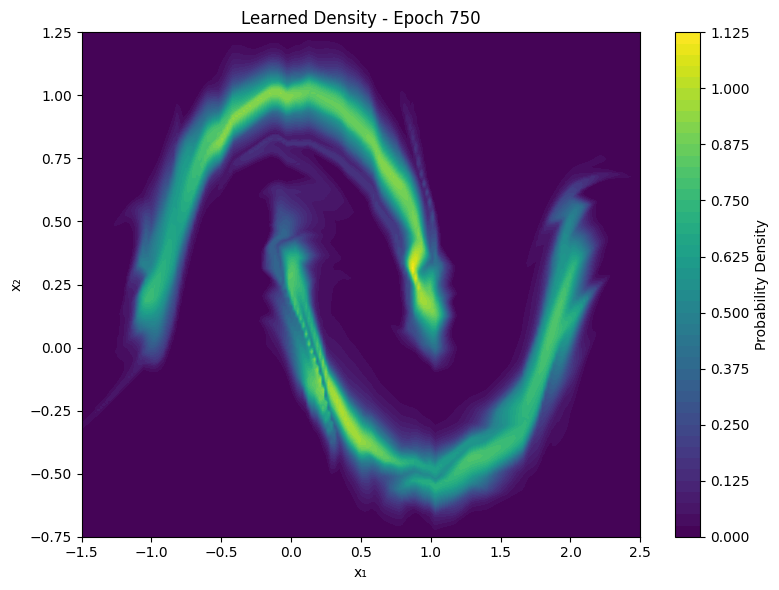

Epoch 999 | Loss: 0.7553: 100%|██████████| 1000/1000 [03:48<00:00,  4.38it/s]


Trained RealNVP in 228.3s; final loss 0.7553


=== Building & training flow: PermutFlow ===


Epoch 0 | Loss: 1.8477:   0%|          | 0/1000 [00:00<?, ?it/s]

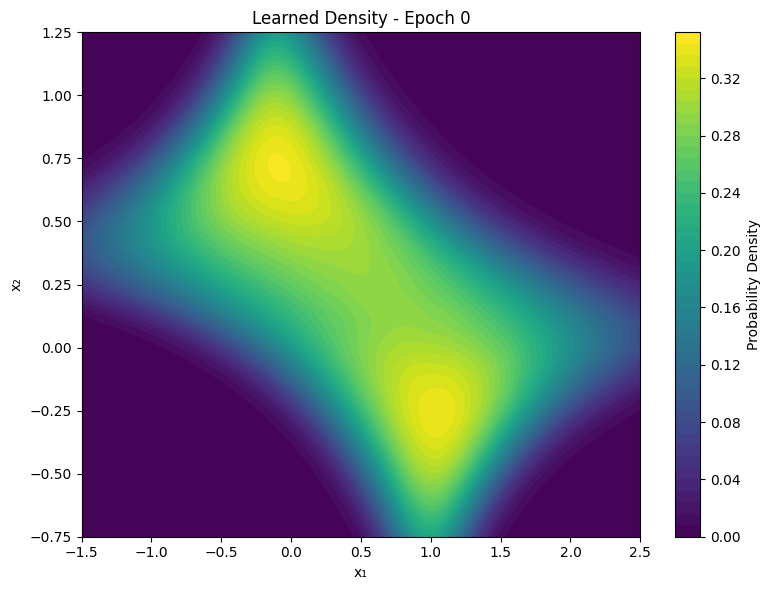

Epoch 250 | Loss: 0.8184:  25%|██▌       | 250/1000 [00:48<02:26,  5.13it/s]

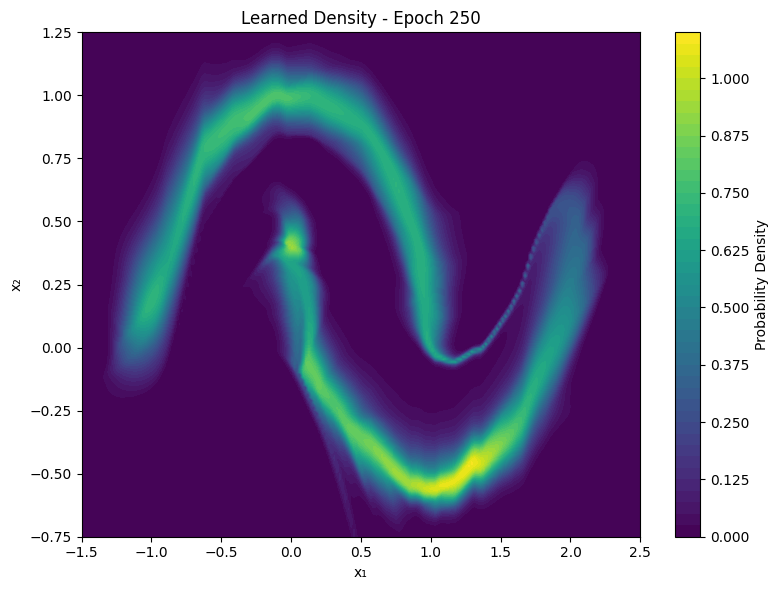

Epoch 500 | Loss: 0.7889:  50%|█████     | 500/1000 [01:38<01:39,  5.01it/s]

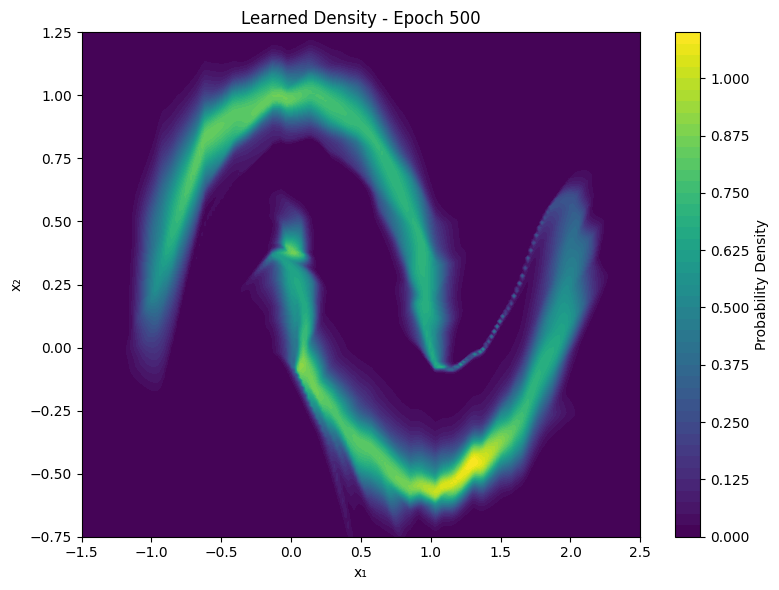

Epoch 750 | Loss: 0.7822:  75%|███████▌  | 750/1000 [02:29<00:49,  5.03it/s]

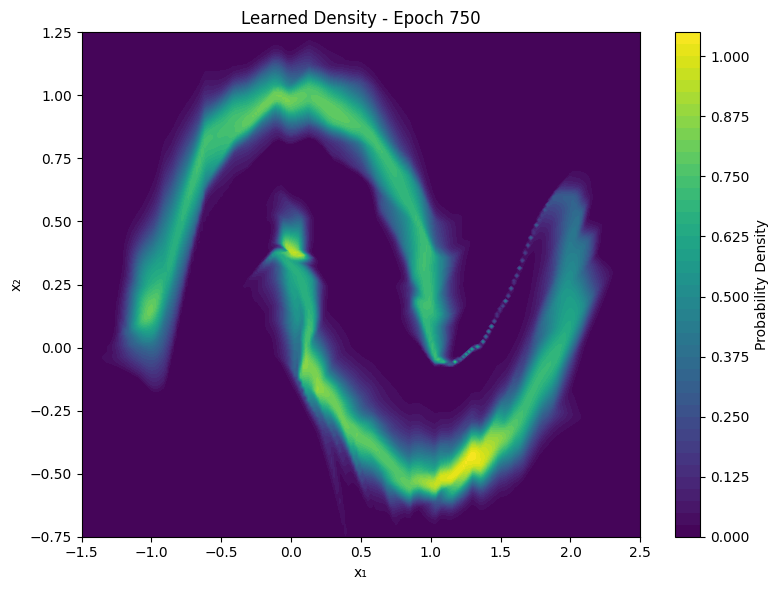

Epoch 999 | Loss: 0.7738: 100%|██████████| 1000/1000 [03:19<00:00,  5.01it/s]

Trained PermutFlow in 199.6s; final loss 0.7738


In [25]:
# Hyperparameters
num_features = 2
hidden_dims = 128
batch_size = 256
learning_rate = 1e-3
num_epochs = 1000
n_couplings=6
num_samples_plot=1000
show_density=True

# Prepare data
X_np, _ = make_moons(n_samples=2000, noise=0.08, random_state=SEED)
X = torch.tensor(X_np, dtype=torch.float32).to(device)

results = {}
flow_names = ['RealNVP', 'PermutFlow']
for name in flow_names:
    print(f"\n========================================")
    print(f"\n=== Building & training flow: {name} ===")
    if name == 'RealNVP':
        flow = build_realnvp_flow(num_features=num_features, n_couplings=n_couplings, hidden_dims=hidden_dims)
    elif name == 'PermutFlow':
        flow = build_permut_flow(num_features=num_features, n_couplings=n_couplings, hidden_dims=hidden_dims)
    else:
        raise ValueError(f"Unknown flow name: {name}")

    start = time.time()
    trained_flow, losses = train_flow(flow, X,
                                      num_epochs=num_epochs,
                                      batch_size=batch_size,
                                      lr=learning_rate,
                                      log_interval=max(1, num_epochs//20),
                                      verbose=True)
    elapsed = time.time() - start
    print(f"Trained {name} in {elapsed:.1f}s; final loss {losses[-1]:.4f}")
    results[name] = {'flow': trained_flow, 'losses': losses}


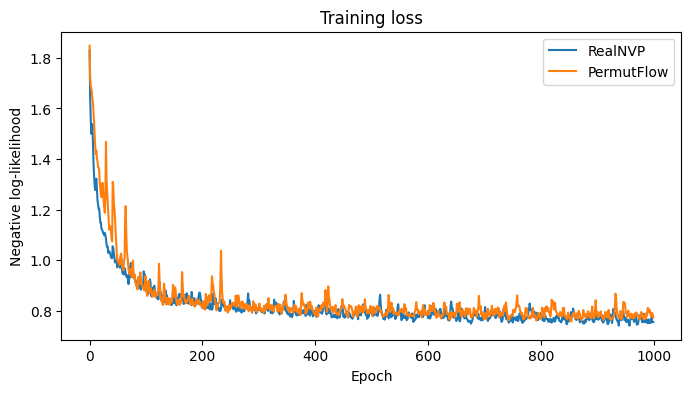

In [26]:
# Plotting training losses
plt.figure(figsize=(8,4))
for name, info in results.items():
    plt.plot(info['losses'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Negative log-likelihood')
plt.legend()
plt.title('Training loss')
plt.show()


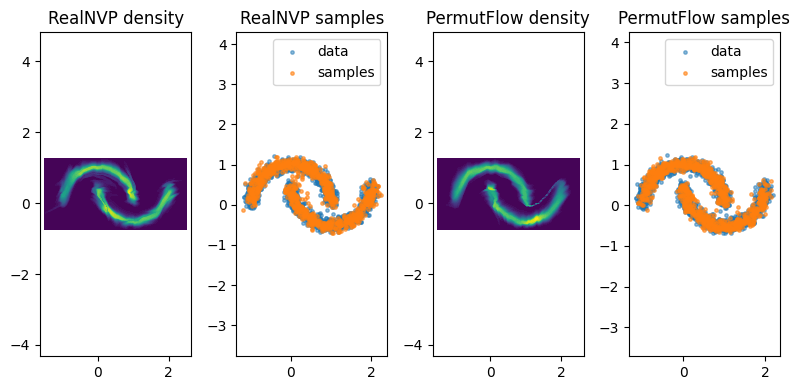

In [27]:
# Plot densities and samples for each model
xline = torch.linspace(-1.5, 2.5, 200, device=device)
yline = torch.linspace(-0.75, 1.25, 200, device=device)
xgrid, ygrid = torch.meshgrid(xline, yline, indexing='ij')
xy = torch.stack([xgrid.flatten(), ygrid.flatten()], dim=1).to(device)

n_variants = len(flow_names)
cols = min(3, n_variants)
rows = int(np.ceil(n_variants / cols))

plt.figure(figsize=(4*cols, 4*rows))
i = 1
for name in flow_names:
    info = results[name]
    f = info['flow']
    with torch.no_grad():
        logp = f.log_prob(xy)
        density = torch.exp(logp).reshape(xgrid.shape).cpu().numpy()
        samples = f.sample(num_samples_plot).cpu().numpy()

    # Density subplot
    plt.subplot(rows, cols*2, 2*(i-1)+1)
    if show_density:
        plt.contourf(xgrid.cpu().numpy(), ygrid.cpu().numpy(), density, levels=50)
        plt.title(f"{name} density")
        plt.axis('equal')
    else:
        plt.title(f"{name} density (hidden)")
        plt.axis('off')

    # Samples subplot
    plt.subplot(rows, cols*2, 2*(i-1)+2)
    plt.scatter(X.cpu().numpy()[:,0], X.cpu().numpy()[:,1], s=6, label='data', alpha=0.5)
    plt.scatter(samples[:,0], samples[:,1], s=6, label='samples', alpha=0.6)
    plt.title(f"{name} samples")
    plt.axis('equal')
    plt.legend()
    i += 1

plt.tight_layout()
plt.show()

# Section 2: Image Inpainting

In [3]:
!pip install normflows --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# Import required packages
import os
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torchvision as tv

import normflows as nf

In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# Make CUDA deterministic *if* you want strict reproducibility (may be slower)
# torch.backends.cudnn.deterministic = False
# torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


Now that we imported the necessary packages, we create a flow model. Glow consists of `nf.flows.GlowBlocks`, that are arranged in a `nf.MultiscaleFlow`, following the multi-scale architecture.


In [6]:
# Define the directory to save checkpoints
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

In [7]:
# Set up model

# Define flows
L = 2
K = 16
torch.manual_seed(SEED)

input_shape = (1, 28, 28)
n_dims = np.prod(input_shape)
channels = 1
hidden_channels = 128
split_mode = 'channel'
scale = True
num_classes = 10

# Set up flows, distributions and merge operations
q0 = []
merges = []
flows = []
for i in range(L):
    flows_ = []
    for j in range(K):
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]
    if i > 0:
        merges += [nf.flows.Merge()]
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i),
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L,
                        input_shape[2] // 2 ** L)
    q0 += [nf.distributions.DiagGaussian(latent_shape)]


# Construct flow model with the multiscale architecture
model = nf.MultiscaleFlow(q0, flows, merges)

/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:923: UserWarning: torch.lu is deprecated in favor of torch.linalg.lu_factor / torch.linalg.lu_factor_ex and will be removed in a future PyTorch release.
LU, pivots = torch.lu(A, compute_pivots)
should be replaced with
LU, pivots = torch.linalg.lu_factor(A, compute_pivots)
and
LU, pivots, info = torch.lu(A, compute_pivots, get_infos=True)
should be replaced with
LU, pivots, info = torch.linalg.lu_factor_ex(A, compute_pivots) (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2064.)
  LU, pivots, infos = torch._lu_with_info(


In [8]:
# Move model on GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [9]:
# @title loading MNIST dataset with TorchVision

batch_size = 128

transform = tv.transforms.Compose([tv.transforms.ToTensor(),
                                   nf.utils.Scale(127. / 128.),
                                   nf.utils.Jitter(1 / 128.)])

train_data = tv.datasets.MNIST('datasets/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

test_data = tv.datasets.MNIST('datasets/', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.63MB/s]


## Training

Now, we can train the model on the image data. If you were not able to do this load the model from the state dict included in the exercise zip file.

In [10]:
max_iter = 15000 # set this based on your GPU limitations (e.g. 10000)
save_every = 2000
lr = 1e-3
weight_decay = 1e-5
grad_clip = 5.0

optimizer = torch.optim.Adamax(model.parameters(), lr=lr, weight_decay=weight_decay)

loss_hist = []

train_iter = iter(train_loader)
pbar = tqdm(range(max_iter), desc="Training")

for it in pbar:
    # fetch batch
    try:
        x, _ = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, _ = next(train_iter)

    x = x.to(device)   # shape [B, C, H, W]

    optimizer.zero_grad()
    # forward_kld returns negative log-likelihood (per-batch or per-sample) depending on implementation.
    # we take mean to get a scalar
    loss = model.forward_kld(x).mean()

    # check for nan/inf safely and skip update if present
    if torch.isfinite(loss):
        loss.backward()
        # optional gradient clipping to stabilize training
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
    else:
        print(f"Skipping iteration {it} due to non-finite loss:", loss)

    loss_val = loss.detach().cpu().item()
    loss_hist.append(loss_val)
    pbar.set_postfix({'loss': f'{loss_val:.4f}'})

    # Save checkpoint periodically
    if (it + 1) % save_every == 0 or (it + 1) == max_iter:
        checkpoint_path = os.path.join(checkpoint_dir, f'model_iter_{it+1}.pth')
        torch.save({
            'iteration': it + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_hist': np.array(loss_hist, dtype=np.float32),
        }, checkpoint_path)
        print(f'\nCheckpoint saved at iteration {it+1} to {checkpoint_path}')



Training:  13%|█▎        | 2000/15000 [03:25<28:58,  7.48it/s, loss=-2837.3840]


Checkpoint saved at iteration 2000 to checkpoints/model_iter_2000.pth


Training:  27%|██▋       | 4000/15000 [06:50<29:49,  6.15it/s, loss=-2949.2896]


Checkpoint saved at iteration 4000 to checkpoints/model_iter_4000.pth


Training:  40%|████      | 6001/15000 [10:15<18:20,  8.18it/s, loss=-2999.2000]

...


Checkpoint saved at iteration 12000 to checkpoints/model_iter_12000.pth


Training:  93%|█████████▎| 14001/15000 [23:58<02:32,  6.56it/s, loss=-3065.4897]


Checkpoint saved at iteration 14000 to checkpoints/model_iter_14000.pth


Training: 100%|██████████| 15000/15000 [25:41<00:00,  9.73it/s, loss=-3087.1658]


Checkpoint saved at iteration 15000 to checkpoints/model_iter_15000.pth


In [11]:
# Save final
final_checkpoint_path = os.path.join(checkpoint_dir, 'model_final.pth')
torch.save({
    'iteration': max_iter,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_hist': np.array(loss_hist, dtype=np.float32),
}, final_checkpoint_path)
print('Training complete. Final model saved to', final_checkpoint_path)


Training complete. Final model saved to checkpoints/model_final.pth


In [15]:
# @title Use this to load final model.

# Load the saved state_dict
#model.load_state_dict(torch.load('/kaggle/working/checkpoints/model_final.pth')['model_state_dict'])

In [18]:
# @title Use this to load checkpoint.

# # Load the checkpoint
checkpoint = torch.load('/kaggle/working/checkpoints/model_iter_15000.pth',weights_only=False)  # Replace with your checkpoint file

# # Load the model state_dict
model.load_state_dict(checkpoint['model_state_dict'])

# # Load the optimizer state_dict
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# # Optionally, load other information
start_iter = checkpoint['iteration']
loss_hist = checkpoint['loss_hist']

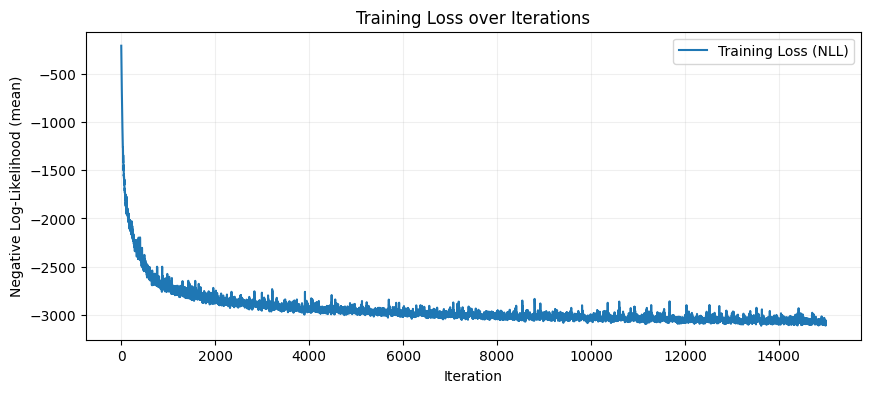

In [19]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_hist, label='Training Loss (NLL)')
plt.xlabel('Iteration')
plt.ylabel('Negative Log-Likelihood (mean)')
plt.legend()
plt.title('Training Loss over Iterations')
plt.grid(alpha=0.2)
plt.show()

## Evaluation

To evaluate our model, we first draw samples from our model. When sampling, we can specify the classes, so we draw the samples from each class.

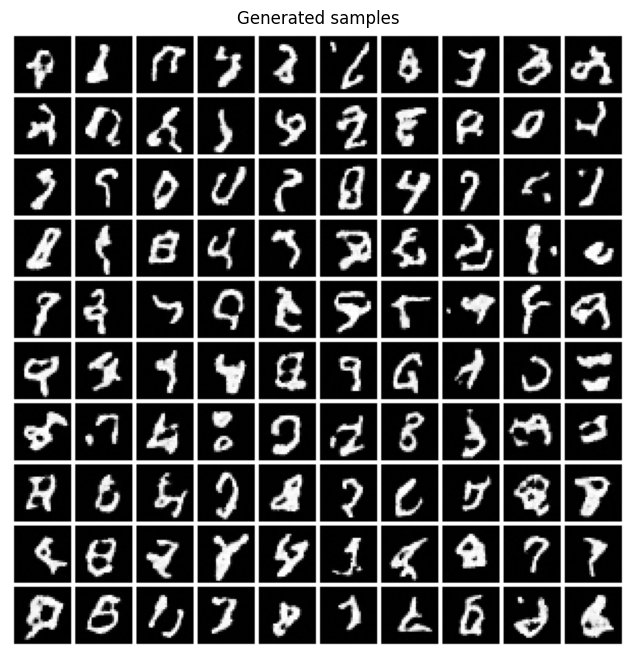

In [20]:
num_samples_per_row = 10
n_samples = num_samples_per_row ** 2

model.eval()
with torch.no_grad():
    x_samples, _ = model.sample(n_samples)  # probably returns tensor in same scale as inputs
    x_clamped = torch.clamp(x_samples, 0.0, 1.0)  # if transform expects [0,1] display
    grid = tv.utils.make_grid(x_clamped.cpu(), nrow=num_samples_per_row, pad_value=1.0)

plt.figure(figsize=(8, 8))
# if single-channel, squeeze channel axis into colormap
if grid.shape[0] == 1:
    plt.imshow(grid.squeeze(0), cmap='gray')
else:
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis('off')
plt.title('Generated samples')
plt.show()

Note that to get competitive performance, a much larger model then specified in this notebook, which is trained over more iterations, is needed.

## In-Painting

In [22]:
#@title Inpainting utilities

def apply_random_square_mask(image, mask_size=8):
  
    C, H, W = image.shape
    assert C == 1 or C == 3
    
    # Create masked_image as a clone of image
    masked_image = image.clone()
    
    # Create mask tensor of zeros with shape [H,W]
    mask = torch.zeros(H, W, dtype=torch.float32, device=image.device)
    
    # Randomly select top-left corner of square mask
    top = np.random.randint(0, H - mask_size + 1)
    left = np.random.randint(0, W - mask_size + 1)
    
    # Set pixels in the square region to 0 in masked_image
    masked_image[:, top:top+mask_size, left:left+mask_size] = 0
    
    # Set corresponding region to 1 in mask
    mask[top:top+mask_size, left:left+mask_size] = 1
    
    return masked_image, mask


def apply_random_noise_mask(image, noise_fraction=0.2):
    
    C, H, W = image.shape
    
    # Clone image to masked_image
    masked_image = image.clone()
    
    # Create mask tensor of zeros [H,W]
    mask = torch.zeros(H, W, dtype=torch.float32, device=image.device)
    
    # Compute number of pixels to mask
    num_noise = int(noise_fraction * H * W)
    
    # Randomly choose pixel indices to mask
    flat_indices = np.random.choice(H * W, size=num_noise, replace=False)
    
    # Convert flat indices to 2D coordinates (ys, xs)
    ys = flat_indices // W
    xs = flat_indices % W
    
    # For each channel, fill selected pixels with random noise in [-1,1]
    for c in range(C):
        noise = torch.rand(num_noise, device=image.device) * 2 - 1  # Range [-1, 1]
        masked_image[c, ys, xs] = noise
    
    # Mark masked positions as 1 in mask
    mask[ys, xs] = 1
    
    return masked_image, mask


def visualize_masking(original_image, masked_image, mask, title="Masking Example"):
   
    orig = original_image.squeeze().cpu().numpy()
    masked = masked_image.squeeze().cpu().numpy()
    mask_np = mask.cpu().numpy()
    
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    
    axs[0].imshow(orig, cmap='gray')
    axs[0].set_title("Original")
    axs[0].axis('off')
    
    axs[1].imshow(masked, cmap='gray')
    axs[1].set_title("Masked")
    axs[1].axis('off')
    
    axs[2].imshow(mask_np, cmap='gray')
    axs[2].set_title("Mask")
    axs[2].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

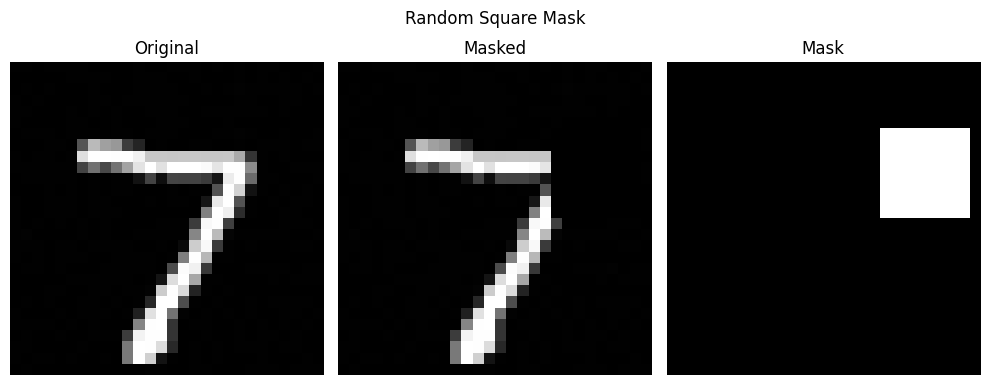

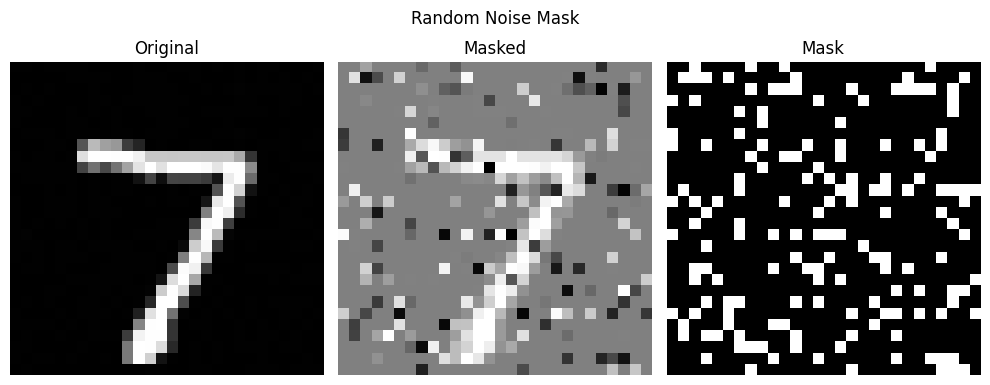

In [23]:
# Example single image from test set
sample_batch = next(iter(test_loader))
sample_image = sample_batch[0][0]  # first sample, shape [C,H,W]

masked_image_sq, mask_sq = apply_random_square_mask(sample_image, mask_size=8)
visualize_masking(sample_image, masked_image_sq, mask_sq, title="Random Square Mask")

masked_image_n, mask_n = apply_random_noise_mask(sample_image, noise_fraction=0.2)
visualize_masking(sample_image, masked_image_n, mask_n, title="Random Noise Mask")

In [29]:
def inpaint_image(model, masked_image, mask, device,
                  num_steps=200, lr=0.01, verbose=True):
    """
    Inpaint a single image using a trained flow model.
    
    Args:
        model: Trained flow model
        masked_image: [C,H,W] tensor, with masked pixels to reconstruct
        mask: [H,W] binary tensor (1 = missing, 0 = observed)
        device: 'cpu' or 'cuda'
        num_steps: number of optimization steps
        lr: learning rate for delta
        verbose: show progress bar
        
    Returns:
        reconstructed image [C,H,W] (on CPU)
    """
    model.eval()
    
    # Move tensors to device
    masked_image = masked_image.to(device)
    mask = mask.to(device)
    
    C, H, W = masked_image.shape
    
    # Create optimization variable `delta` for masked pixels
    delta = torch.zeros_like(masked_image, device=device)
    delta.data = torch.randn_like(masked_image, device=device) * 0.01
    delta.requires_grad = True
    
    # Define optimizer to update only delta
    optimizer = optim.Adam([delta], lr=lr)
    
    # Progress bar
    pbar = tqdm(range(num_steps), disable=not verbose, desc="Inpainting")
    
    for step in pbar:
        # Zero gradients
        optimizer.zero_grad()
        
        # Reconstruct full image:
        # - Observed pixels (mask=0): use original masked_image values
        # - Missing pixels (mask=1): use masked_image + delta
        # Expand mask to match image channels
        mask_expanded = mask.unsqueeze(0).expand(C, -1, -1)  # [C,H,W]
        
        reconstructed = masked_image + delta * mask_expanded
        
        # Add batch dimension for model input [1,C,H,W]
        reconstructed_batch = reconstructed.unsqueeze(0)
        
        # Try different ways to compute log_prob based on model type
        try:
            # Standard Flow interface
            log_prob = model.log_prob(reconstructed_batch)
        except TypeError:
            try:
                # MultiscaleFlow might need (x, y) where y is the target
                # Or it might use forward() differently
                # Check if model has forward_kld method
                if hasattr(model, 'forward_kld'):
                    loss = model.forward_kld(reconstructed_batch)
                    loss.backward()
                    optimizer.step()
                    
                    # Clamp
                    with torch.no_grad():
                        reconstructed = masked_image + delta * mask_expanded
                        reconstructed.clamp_(0, 1)
                        delta.data = (reconstructed - masked_image) / (mask_expanded + 1e-8)
                    
                    if verbose:
                        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
                    continue
                else:
                    # Try forward method which might return (z, log_det)
                    z, log_det = model.forward(reconstructed_batch)
                    # Compute log prob manually
                    log_prob_z = model.base_distribution.log_prob(z)
                    log_prob = log_prob_z + log_det
            except Exception as e:
                raise TypeError(f"Could not compute log_prob. Model type: {type(model)}. Error: {e}")
        
        loss = -log_prob.mean()
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Clamp reconstructed pixels to valid range [0, 1]
        with torch.no_grad():
            reconstructed = masked_image + delta * mask_expanded
            reconstructed.clamp_(0, 1)
            # Update delta to maintain valid range
            delta.data = (reconstructed - masked_image) / (mask_expanded + 1e-8)
        
        # Update progress bar
        if verbose:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Return final reconstructed image on CPU
    with torch.no_grad():
        mask_expanded = mask.unsqueeze(0).expand(C, -1, -1)
        final_reconstructed = masked_image + delta * mask_expanded
        final_reconstructed.clamp_(0, 1)
    
    return final_reconstructed.cpu()


def inpaint_batch(model, masked_images, masks, device, num_steps=200, lr=0.01):
   
    model.eval()
    
    # Create empty list to store results
    inpainted_list = []
    
    N = masked_images.shape[0]
    
    # Loop over batch dimension and call inpaint_image for each
    print(f"Inpainting {N} images...")
    for i in range(N):
        # Extract single image and mask
        single_masked = masked_images[i]  # [C,H,W]
        single_mask = masks[i]  # [H,W]
        
        # Inpaint single image
        inpainted = inpaint_image(
            model, 
            single_masked, 
            single_mask, 
            device,
            num_steps=num_steps,
            lr=lr,
            verbose=(i == 0)  # Only show progress for first image
        )
        
        # Append to list
        inpainted_list.append(inpainted)
        
        if i > 0 and (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{N} images")
    
    # Stack all results into [N,C,H,W] tensor
    inpainted_images = torch.stack(inpainted_list, dim=0)
    
    return inpainted_images


def visualize_inpainting_results(original, masked, mask, inpainted, title="Inpainting Results"):
   
    fig, axs = plt.subplots(1, 4, figsize=(14, 4))
    
    # Convert to numpy and squeeze channel dimension if grayscale
    orig_np = original.squeeze().cpu().numpy()
    masked_np = masked.squeeze().cpu().numpy()
    mask_np = mask.cpu().numpy()
    inpainted_np = inpainted.squeeze().cpu().numpy()
    
    axs[0].imshow(orig_np, cmap='gray')
    axs[0].set_title("Original")
    axs[0].axis('off')
    
    axs[1].imshow(masked_np, cmap='gray')
    axs[1].set_title("Masked")
    axs[1].axis('off')
    
    axs[2].imshow(mask_np, cmap='gray')
    axs[2].set_title("Mask")
    axs[2].axis('off')
    
    axs[3].imshow(inpainted_np, cmap='gray')
    axs[3].set_title("Inpainted")
    axs[3].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [30]:
model = model.to(device)
model.eval()

# take a small batch
batch_images, _ = next(iter(test_loader))
batch_images = batch_images[:4]  # N=4
masked_imgs = []
masks = []
for img in batch_images:
    mimg, m = apply_random_square_mask(img, mask_size=8)
    masked_imgs.append(mimg)
    masks.append(m)
masked_imgs = torch.stack(masked_imgs)
masks = torch.stack(masks)

# Run inpainting (note: might be slow; lower num_steps to test)
inpainted = inpaint_batch(model, masked_imgs, masks, device, num_steps=200, lr=0.01)

Inpainting 4 images...


Inpainting: 100%|██████████| 200/200 [00:16<00:00, 12.05it/s, loss=-3225.0859]


**NOTE**: Actually getting good in-paintings requires a bigger model. So your score will be determined based on your codes logic and and your outputs being without logic/code bugs.

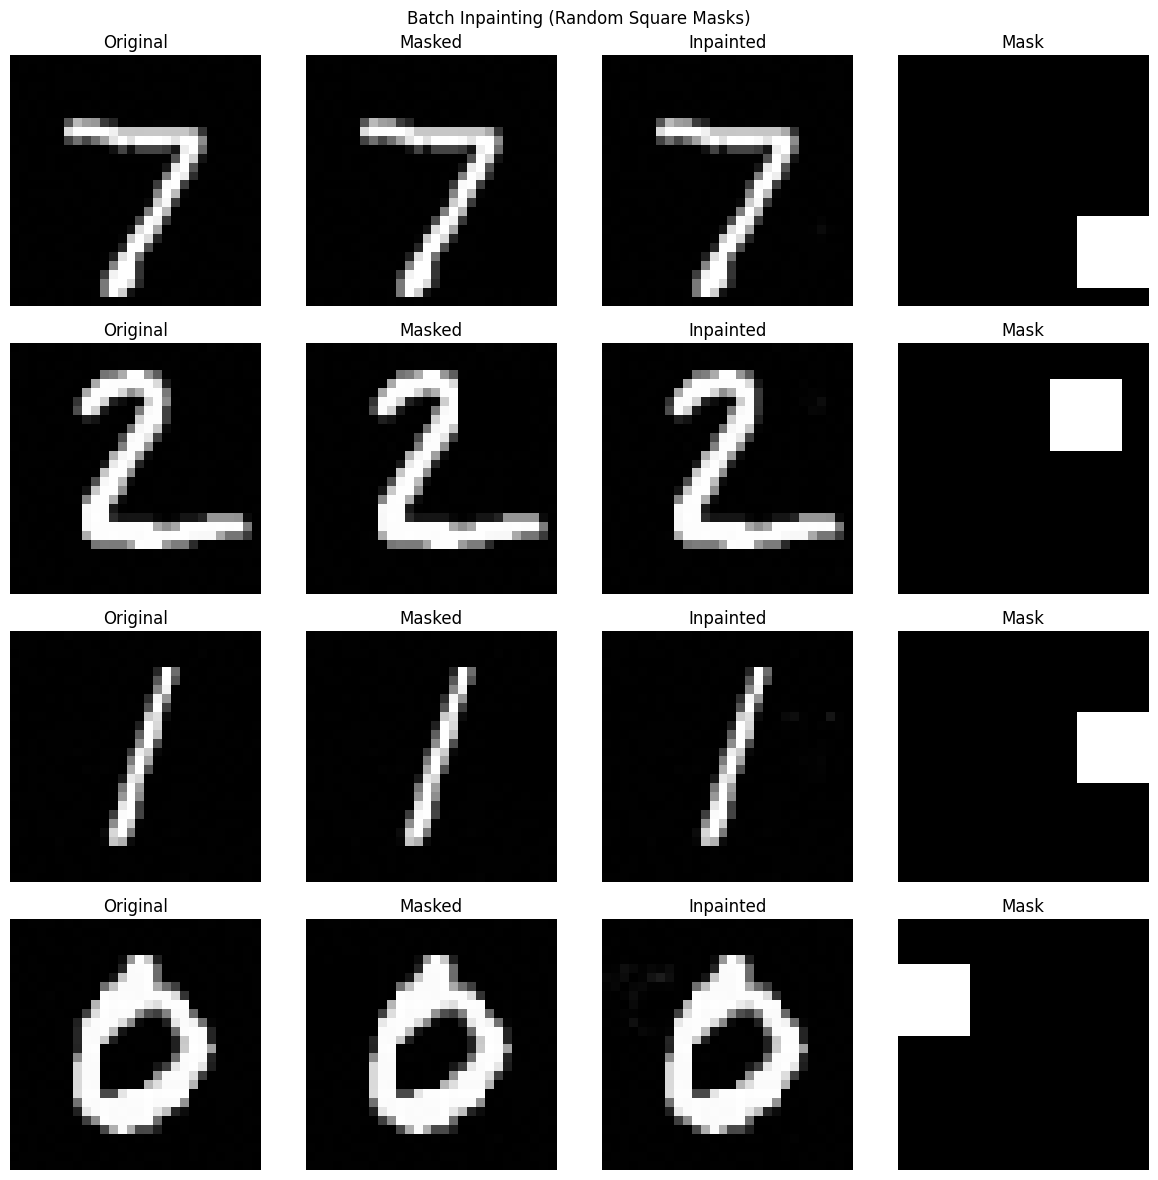

In [31]:
def visualize_batch_inpainting(originals, masked, inpainted, masks, title="Batch Inpainting Results"):
    N = originals.size(0)
    fig, axs = plt.subplots(N, 4, figsize=(12, 3 * N))
    for i in range(N):
        orig = originals[i].squeeze().cpu().numpy()
        maskd = masked[i].squeeze().cpu().numpy()
        inp = inpainted[i].squeeze().cpu().numpy()
        m = masks[i].cpu().numpy()

        axs[i,0].imshow(orig, cmap='gray'); axs[i,0].set_title('Original'); axs[i,0].axis('off')
        axs[i,1].imshow(maskd, cmap='gray'); axs[i,1].set_title('Masked'); axs[i,1].axis('off')
        axs[i,2].imshow(inp, cmap='gray'); axs[i,2].set_title('Inpainted'); axs[i,2].axis('off')
        axs[i,3].imshow(m, cmap='gray'); axs[i,3].set_title('Mask'); axs[i,3].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_batch_inpainting(batch_images, masked_imgs, inpainted, masks, title="Batch Inpainting (Random Square Masks)")